In [80]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    # print(list(ea.Scalars(tag)))
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test)
                                        print(event_dir)


                                        if os.path.exists(event_dir):
                                            print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, test_global_grad = parse_tf_events_file(event_dir, tag="Test/GradNorm")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            _, train_global_grad = parse_tf_events_file(event_dir, tag="Train/GradNorm")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

main_folder = 'cifar10_group_notclip_v5'
# ['1e-1', '1e-2', '1e-3', '1e-4', "5e-2"]

availabilities="alphaF-110sl-1cb-3ft alphaF-130sl-1cb-3ft alphaF-150sl-1cb-3ft alphaF-170sl-1cb-3ft alphaF-190sl-1cb-3ft alphaF-95sl-2cb-3ft alphaF-115sl-2cb-3ft alphaF-135sl-2cb-3ft alphaF-155sl-2cb-3ft alphaF-175sl-2cb-3ft alphaF-80sl-3cb-3ft alphaF-100sl-3cb-3ft alphaF-120sl-3cb-3ft alphaF-140sl-3cb-3ft alphaF-160sl-3cb-3ft alphaF-65sl-4cb-3ft alphaF-85sl-4cb-3ft alphaF-105sl-4cb-3ft alphaF-125sl-4cb-3ft alphaF-145sl-4cb-3ft alphaF-50sl-5cb-3ft alphaF-70sl-5cb-3ft alphaF-90sl-5cb-3ft alphaF-110sl-5cb-3ft alphaF-130sl-5cb-3ft alphaF-35sl-6cb-3ft alphaF-55sl-6cb-3ft alphaF-75sl-6cb-3ft alphaF-95sl-6cb-3ft alphaF-115sl-6cb-3ft alphaF-25sl-7cb-3ft alphaF-45sl-7cb-3ft alphaF-65sl-7cb-3ft".split() # list of availability matrices

config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment=main_folder, seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-2','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df = get_exp_stats(config)

config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-2','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=["alphaF-0cb-3ft"],
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")
results_df_baseline = get_exp_stats(config)
results_df = pd.concat([results_df, results_df_baseline])


results_df

import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
# for availability_value, group in results_df.groupby("availability"):
    
#     plt.figure(figsize=(10, 6))
    
#     for _, row in group.iterrows():
#         label = f"lr={row['lr']} | seed={row['seed']}"
#         plt.plot(row['test_accuracy'], label=label)
    
#     plt.title(f"Test Accuracy Curves — availability = {availability_value}")
#     plt.xlabel("Epoch")
#     plt.ylabel("Test Accuracy")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10", seeds=["42", '78', '84'],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=['5e-2','1e-2'], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=["alphaF-0cb-3ft"],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

# results_df = load_experiment_results(config)
# # plot_availability_comparison_mean_seed(config, results_df, "test_accuracy", folder=main_folder+'/comp-av-mat/ft')

../logs/cifar10_group_notclip_v5/alphaF-110sl-1cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-130sl-1cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-150sl-1cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-170sl-1cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-190sl-1cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-95sl-2cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-115sl-2cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-135sl-2cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-155sl-2cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
..

In [2]:
results_df['len']=results_df[['availability','seed','lr','test_accuracy']].apply(lambda x: len(x['test_accuracy']), axis=1)

In [5]:
results_df.groupby("availability")['len'].apply(np.mean)

availability
alphaF-100sl-3cb-3ft    101.0
alphaF-105sl-4cb-3ft    106.0
alphaF-110sl-1cb-3ft    111.0
alphaF-110sl-5cb-3ft    111.0
alphaF-115sl-2cb-3ft    116.0
alphaF-115sl-6cb-3ft    116.0
alphaF-120sl-3cb-3ft    121.0
alphaF-125sl-4cb-3ft    126.0
alphaF-130sl-1cb-3ft    131.0
alphaF-130sl-5cb-3ft    131.0
alphaF-135sl-2cb-3ft    136.0
alphaF-140sl-3cb-3ft    141.0
alphaF-145sl-4cb-3ft    146.0
alphaF-150sl-1cb-3ft    151.0
alphaF-155sl-2cb-3ft    156.0
alphaF-160sl-3cb-3ft    161.0
alphaF-170sl-1cb-3ft    171.0
alphaF-175sl-2cb-3ft    176.0
alphaF-190sl-1cb-3ft    191.0
alphaF-25sl-7cb-3ft      26.0
alphaF-35sl-6cb-3ft      36.0
alphaF-45sl-7cb-3ft      46.0
alphaF-50sl-5cb-3ft      51.0
alphaF-55sl-6cb-3ft      56.0
alphaF-65sl-4cb-3ft      66.0
alphaF-65sl-7cb-3ft      66.0
alphaF-70sl-5cb-3ft      71.0
alphaF-75sl-6cb-3ft      76.0
alphaF-80sl-3cb-3ft      81.0
alphaF-85sl-4cb-3ft      86.0
alphaF-90sl-5cb-3ft      91.0
alphaF-95sl-2cb-3ft      96.0
alphaF-95sl-6cb-3ft      96

In [81]:
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['std_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.std(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['final_std_acc'] = tmp['std_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

In [82]:
T_map = [100,90,75,60,45,30,15,5]

tmp = modify_data(results_df)

tmp = tmp.loc[tmp.groupby('availability')['final_mean_acc'].idxmax()]
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg')]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)


fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(100).astype(int)
fed_avg['s'] = fed_avg['slack_time'] - fed_avg['avail_mat'].map(lambda x: T_map[x])
fed_avg.sort_values(['avail_mat','s'], inplace=True)



In [29]:
fed_avg = fed_avg.loc[fed_avg["avail_mat"]!=7]

In [83]:
base_test_acc = fed_avg.loc[fed_avg['avail_mat'] == 0, 'mean_test_acc'].values[0].take([100,90,75,60,45,30,15,5]) *100 # 100,90,75,60,45,30,15,5
base_test_std_acc = fed_avg.loc[fed_avg['avail_mat'] == 0, 'std_test_acc'].values[0].take([100,90,75,60,45,30,15,5]) *100 

In [84]:
perc_cb_used = [100.0,
                86.03754606747044,
                64.34157007056174,
                48.57710810495588,
                36.59564700520919,
                25.653291413710384,
                12.555690542858041,
 3.903694502135956
 ]

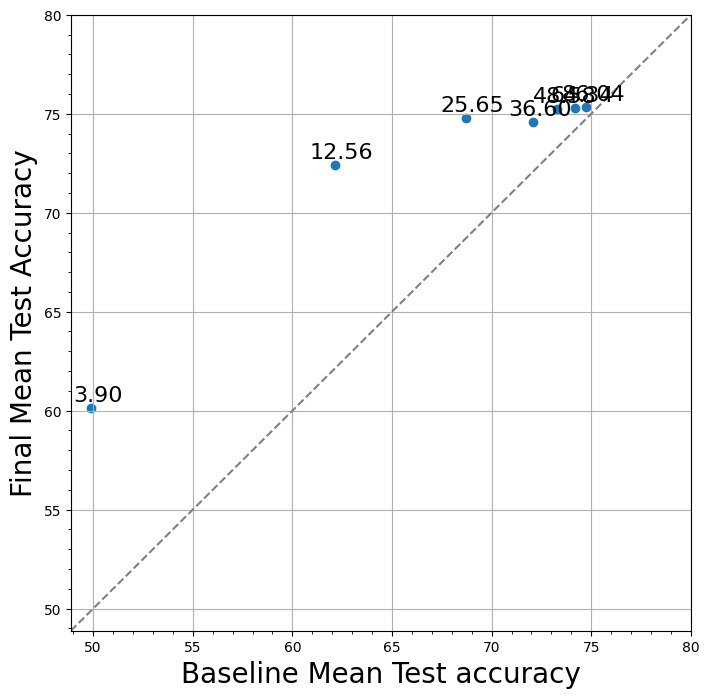

In [85]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc[1:],
    _tmp['final_mean_acc'].values[1:]*100,
    marker='o', 
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values[1:]):
    plt.annotate(
        # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
        f'{perc_cb_used[i+1]:.2f}', 
        (base_test_acc[i+1],val[0]*100), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=16
    )

x_min = min(min(base_test_acc[1:]), min(_tmp['final_mean_acc'].values[1:]*100))


plt.plot([x_min-1, 80.0], [x_min-1, 80.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 80.0)
plt.ylim(x_min-1, 80.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
# plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()


In [86]:
df = fed_avg[['avail_mat', 's', 'final_mean_acc', 'final_std_acc']].sort_values(['avail_mat', 's']).__deepcopy__()
df["acc_str"] = df.apply(
    lambda r: f"{100*r.final_mean_acc:.2f} ({100*r.final_std_acc:.2f})",
    axis=1
)

# 2. Pivot table
df_wide = df.pivot(
    index="avail_mat",
    columns="s",
    values="acc_str"
)

# 3. (Optional) sort columns numerically
df_wide = df_wide.sort_index(axis=1)

# 4. Reset index if you want avail_mat as a column
df_wide = df_wide.reset_index()
df.loc[df.groupby("avail_mat")["final_mean_acc"].idxmax()]

,avail_mat,s,final_mean_acc,final_std_acc,acc_str
1,0,0,0.750533,0.002130,75.05 (0.21)
39,1,100,0.753200,0.002736,75.32 (0.27)
37,2,100,0.752800,0.002263,75.28 (0.23)
33,3,100,0.752300,0.001551,75.23 (0.16)
17,4,80,0.745667,0.002641,74.57 (0.26)
21,5,100,0.747767,0.006486,74.78 (0.65)
49,6,40,0.724233,0.005448,72.42 (0.54)
41,7,20,0.601300,0.006101,60.13 (0.61)


In [87]:
df_wide

s,avail_mat,0,20,40,60,80,100
0,0,75.05 (0.21),NaN,NaN,NaN,NaN,NaN
1,1,NaN,74.71 (0.16),74.75 (0.12),75.16 (0.21),75.00 (0.32),75.32 (0.27)
2,2,NaN,74.33 (0.32),74.54 (0.23),75.06 (0.18),75.04 (0.10),75.28 (0.23)
3,3,NaN,74.03 (0.13),74.54 (0.17),74.54 (0.30),74.91 (0.35),75.23 (0.16)
4,4,NaN,73.42 (0.26),74.26 (0.31),74.54 (0.23),74.57 (0.26),74.47 (0.28)
5,5,NaN,71.82 (0.29),73.28 (0.47),74.48 (0.39),74.64 (0.37),74.78 (0.65)
6,6,NaN,69.32 (0.22),72.42 (0.54),71.54 (0.34),68.95 (0.24),67.30 (0.14)
7,7,NaN,60.13 (0.61),54.05 (1.13),47.45 (2.70),NaN,NaN


# For 1 ft

In [68]:
main_folder = 'cifar10_group_notclip_v5'
# ['1e-1', '1e-2', '1e-3', '1e-4', "5e-2"]

availabilities="alphaF-110sl-1cb-1ft alphaF-130sl-1cb-1ft alphaF-150sl-1cb-1ft alphaF-170sl-1cb-1ft alphaF-190sl-1cb-1ft alphaF-115sl-2cb-1ft alphaF-135sl-2cb-1ft alphaF-155sl-2cb-1ft alphaF-175sl-2cb-1ft alphaF-95sl-2cb-1ft alphaF-100sl-3cb-1ft alphaF-120sl-3cb-1ft alphaF-140sl-3cb-1ft alphaF-160sl-3cb-1ft alphaF-80sl-3cb-1ft alphaF-105sl-4cb-1ft alphaF-125sl-4cb-1ft alphaF-145sl-4cb-1ft alphaF-65sl-4cb-1ft alphaF-85sl-4cb-1ft alphaF-110sl-5cb-1ft alphaF-130sl-5cb-1ft alphaF-50sl-5cb-1ft alphaF-70sl-5cb-1ft alphaF-90sl-5cb-1ft alphaF-115sl-6cb-1ft alphaF-35sl-6cb-1ft alphaF-55sl-6cb-1ft alphaF-75sl-6cb-1ft alphaF-95sl-6cb-1ft alphaF-105sl-7cb-1ft alphaF-25sl-7cb-1ft alphaF-45sl-7cb-1ft alphaF-65sl-7cb-1ft alphaF-85sl-7cb-1ft alphaF-103sl-8cb-1ft alphaF-23sl-8cb-1ft alphaF-43sl-8cb-1ft alphaF-63sl-8cb-1ft alphaF-83sl-8cb-1ft".split() # list of availability matrices

config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment=main_folder, seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-2','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df_1ft = pd.concat([results_df_baseline,get_exp_stats(config)])


import ast

# Convert 'test_accuracy' column to lists if needed
results_df_1ft['test_accuracy'] = results_df_1ft['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


../logs/cifar10_group_notclip_v5/alphaF-110sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-130sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-150sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-170sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-190sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-115sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-135sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-155sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v5/alphaF-175sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-2/seed_42/train/global
x
.

In [69]:


tmp = modify_data(results_df)

tmp = tmp.loc[tmp.groupby('availability')['final_mean_acc'].idxmax()]
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg')]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)


fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(100).astype(int)
fed_avg['s'] = fed_avg['slack_time'] - fed_avg['avail_mat'].map(lambda x: T_map[x])
fed_avg.sort_values(['avail_mat','s'], inplace=True)

In [70]:
T_map = [100,90,75,60,45,30,15,5,3]
tmp = modify_data(results_df_1ft)

tmp = tmp.loc[tmp.groupby('availability')['final_mean_acc'].idxmax()]
fed_avg_1ft = tmp.loc[(tmp['algorithm'] == 'fedavg')]
fed_avg_1ft['avail_mat'] = fed_avg_1ft['availability'].str.extract(r'-(\d+)cb')
fed_avg_1ft['avail_mat'] = fed_avg_1ft['avail_mat'].fillna(0).astype(int)


fed_avg_1ft['slack_time'] = fed_avg_1ft['availability'].str.extract(r'-(\d+)sl')
fed_avg_1ft['slack_time'] = fed_avg_1ft['slack_time'].fillna(100).astype(int)

fed_avg_1ft['s'] = fed_avg_1ft['slack_time'] - fed_avg_1ft['avail_mat'].map(lambda x: T_map[x])
fed_avg_1ft.sort_values(['avail_mat','s'], inplace=True)

In [47]:
fed_avg_1ft = fed_avg_1ft.loc[~fed_avg_1ft["avail_mat"].isin([7, 8])]

In [71]:
base_test_acc_1ft = fed_avg_1ft.loc[fed_avg_1ft['avail_mat'] == 0, 'mean_test_acc'].values[0].take([100,90,75,60,45,30,15,5,3]) *100 # 100,90,75,60,45,30,15,5,3
base_test_std_acc_1ft = fed_avg_1ft.loc[fed_avg_1ft['avail_mat'] == 0, 'std_test_acc'].values[0].take([100,90,75,60,45,30,15,5,3]) *100 

In [72]:
perc_cb_used_1ft = [100.0,
                    86.03754606747044,
                    64.34157007056174,
                    48.57710810495588,
                    36.59564700520919,
                    25.653291413710384,
                    12.555690542858041,
                    3.903694502135956,
                    2.3083573977423577
 ]

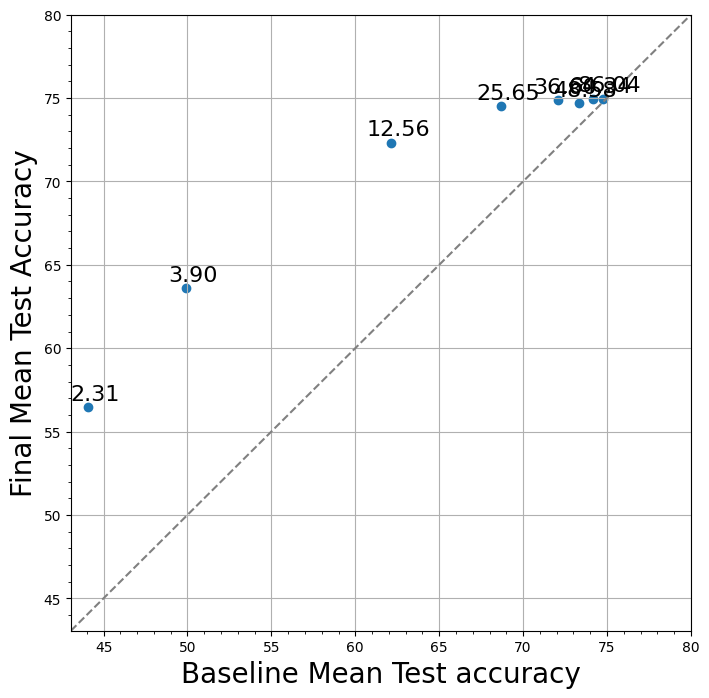

In [73]:
_tmp_1ft = fed_avg_1ft.loc[fed_avg_1ft.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc_1ft[1:],
    _tmp_1ft['final_mean_acc'].values[1:]*100,
    marker='o', 
)

for i, val in enumerate(_tmp_1ft[['final_mean_acc', 'slack_time']].values[1:]):
    plt.annotate(
        # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
        f'{perc_cb_used_1ft[i+1]:.2f}', 
        (base_test_acc_1ft[i+1],val[0]*100), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=16
    )

x_min = min(min(base_test_acc_1ft[1:]), min(_tmp_1ft['final_mean_acc'].values[1:]*100))


plt.plot([x_min-1, 80.0], [x_min-1, 80.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 80.0)
plt.ylim(x_min-1, 80.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
# plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()


In [74]:
df = fed_avg_1ft[['avail_mat', 's', 'final_mean_acc', 'final_std_acc']].sort_values(['avail_mat', 's']).__deepcopy__()
df["acc_str"] = df.apply(
    lambda r: f"{100*r.final_mean_acc:.2f} ({100*r.final_std_acc:.2f})",
    axis=1
)

# 2. Pivot table
df_wide = df.pivot(
    index="avail_mat",
    columns="s",
    values="acc_str"
)

# 3. (Optional) sort columns numerically
df_wide = df_wide.sort_index(axis=1)

# 4. Reset index if you want avail_mat as a column
df_wide = df_wide.reset_index()
df.loc[df.groupby("avail_mat")["final_mean_acc"].idxmax()]

,avail_mat,s,final_mean_acc,final_std_acc,acc_str
1,0,0,0.750533,0.002130,75.05 (0.21)
33,1,60,0.749733,0.001929,74.97 (0.19)
35,2,80,0.749533,0.001255,74.95 (0.13)
37,3,100,0.746867,0.001195,74.69 (0.12)
31,4,100,0.748633,0.002899,74.86 (0.29)
13,5,80,0.744967,0.004012,74.50 (0.40)
57,6,40,0.723300,0.003612,72.33 (0.36)
47,7,20,0.636200,0.002860,63.62 (0.29)
45,8,20,0.564800,0.010752,56.48 (1.08)


In [75]:
df_wide

s,avail_mat,0,20,40,60,80,100
0,0,75.05 (0.21),NaN,NaN,NaN,NaN,NaN
1,1,NaN,74.68 (0.33),74.84 (0.09),74.97 (0.19),74.91 (0.60),74.90 (0.41)
2,2,NaN,74.24 (0.16),74.27 (0.23),74.72 (0.07),74.95 (0.13),74.90 (0.29)
3,3,NaN,74.23 (0.24),74.52 (0.21),74.18 (0.27),74.47 (0.35),74.69 (0.12)
4,4,NaN,73.02 (0.47),74.00 (0.07),74.28 (0.26),74.06 (0.42),74.86 (0.29)
5,5,NaN,72.12 (0.40),73.08 (0.25),74.38 (0.11),74.50 (0.40),73.92 (0.41)
6,6,NaN,69.44 (0.17),72.33 (0.36),71.86 (0.12),70.54 (0.94),70.16 (0.75)
7,7,NaN,63.62 (0.29),56.30 (1.42),46.91 (3.69),48.95 (3.21),34.58 (5.16)
8,8,NaN,56.48 (1.08),43.52 (0.25),50.05 (2.49),24.81 (4.01),22.92 (1.02)


In [79]:
for acc,st in zip(base_test_acc_1ft[1:], base_test_std_acc_1ft[1:]):
    print(f"{acc:.2f} ({st:.2f})")

74.73 (0.21)
74.19 (0.17)
73.30 (0.18)
72.09 (0.11)
68.69 (0.51)
62.13 (0.40)
49.89 (0.52)
44.05 (0.30)


# PLOTS

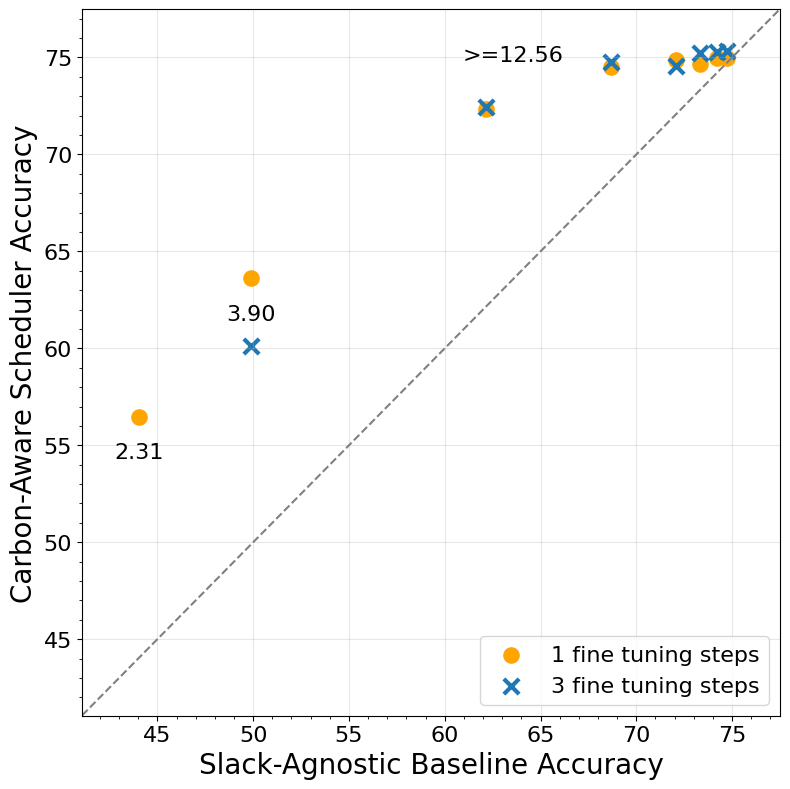

In [103]:
plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc_1ft[1:],
    _tmp_1ft['final_mean_acc'].values[1:]*100,
    marker='o',
    s=120,
    color='orange',
    label='1 fine tuning steps'
)

plt.scatter(
    base_test_acc[1:],
    _tmp['final_mean_acc'].values[1:]*100,
    marker='x',
    s=120,
    linewidths=3,
    color='tab:blue',
    label='3 fine tuning steps'
)

# Annotations
for i, val in enumerate(_tmp_1ft[['final_mean_acc', 'slack_time']].values[1:]):
    if perc_cb_used_1ft[i+1] ==perc_cb_used_1ft[-2]:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'{perc_cb_used_1ft[i+1]:.2f}', 
            (base_test_acc_1ft[i+1],val[0]*100), 
            xytext=(0, -30), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )
    elif perc_cb_used_1ft[i+1] ==perc_cb_used_1ft[-1]:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'{perc_cb_used_1ft[i+1]:.2f}', 
            (base_test_acc_1ft[i+1],val[0]*100), 
            xytext=(0, -30), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )
    elif perc_cb_used_1ft[i+1]==perc_cb_used_1ft[-3]:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'>={perc_cb_used_1ft[i+1]:.2f}', 
            (base_test_acc_1ft[i+1],val[0]*100), 
            xytext=(20, 35), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )
        flg=1

x_min = min(min(base_test_acc_1ft[1:]), min(_tmp_1ft['final_mean_acc'].values[1:]*100))


plt.plot([x_min-5, 77.5], [x_min-5, 77.5], color='gray', linestyle='--')

plt.xlabel('Slack-Agnostic Baseline Accuracy', fontsize=20)
plt.ylabel('Carbon-Aware Scheduler Accuracy', fontsize=20)
# plt.xticks([60, 65, 70, 75, 80])
# plt.yticks([60, 65, 70, 75, 80])
plt.tick_params(axis='both', which='major', labelsize=16)
plt.grid(True, which='major', alpha=0.3)
plt.minorticks_on()
plt.legend(fontsize=16, loc='lower right')


# Set equal x and y limits
plt.xlim(x_min-3, 77.5)
plt.ylim(x_min-3, 77.5)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.savefig("../../cifar10_final_plt.png")

plt.tight_layout()
plt.show()
